## 2 Блок

1 Задание

Выбераю маргинальное распределение X. Генерирую число от 0 до 1. Если случайное число попало в соответствующий интервал накопленной функции распределения, выбираем связанное с ним значение X.

In [19]:
import random
import pandas as pd

sample_size = 10_000

df = pd.read_csv("Вариант 15.csv")

P = df.set_index("XY")
P.columns = P.columns.astype(int)
P.index = P.index.astype(int)
missing = 1 - P.sum().sum()
P = P.sort_index().sort_index(axis=1).fillna(missing)

marginal_x = P.sum(axis=0)
cumulative_x = marginal_x.cumsum()

def generate_x():
    u = random.random()

    for x, probability_limit in cumulative_x.items():
        if u <= probability_limit:
            return x

    return cumulative_x.index[-1]

simulated_x = [generate_x() for _ in range(sample_size)]

simulated_distribution_x = pd.Series(simulated_x).value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    "x": marginal_x.index,
    "P(X = x)": marginal_x.values,
    "Смоделированная частота": [simulated_distribution_x.get(x, 0) for x in marginal_x.index],
})

print(f"Смоделировано значений: {len(simulated_x)}")
print("Первые 20 значений:")
print(simulated_x[:20])

display(
    comparison.style.hide(axis="index").format({
        "P(X = x)": "{:.4f}",
        "Смоделированная частота": "{:.4f}",
    })
)

Смоделировано значений: 10000
Первые 20 значений:
[-23, -11, 58, 63, 58, 67, 63, 84, 87, 63, -92, 58, 24, -92, -92, -74, 67, -74, 67, 87]


x,P(X = x),Смоделированная частота
-92,0.1218,0.1200
-74,0.0925,0.0915
-23,0.1114,0.1135
-11,0.0926,0.0948
24,0.0909,0.0940
58,0.0851,0.0828
63,0.1397,0.1419
67,0.1173,0.1157
84,0.0544,0.0552
87,0.0943,0.0906


2 Задание

x,P(X = x),Относительная частота,Разность
-92,0.121800,0.120000,-0.001800
-74,0.092500,0.091500,-0.001000
-23,0.111400,0.113500,0.002100
-11,0.092600,0.094800,0.002200
24,0.090900,0.094000,0.003100
58,0.085100,0.082800,-0.002300
63,0.139700,0.141900,0.002200
67,0.117300,0.115700,-0.001600
84,0.054400,0.055200,0.000800
87,0.094300,0.090600,-0.003700


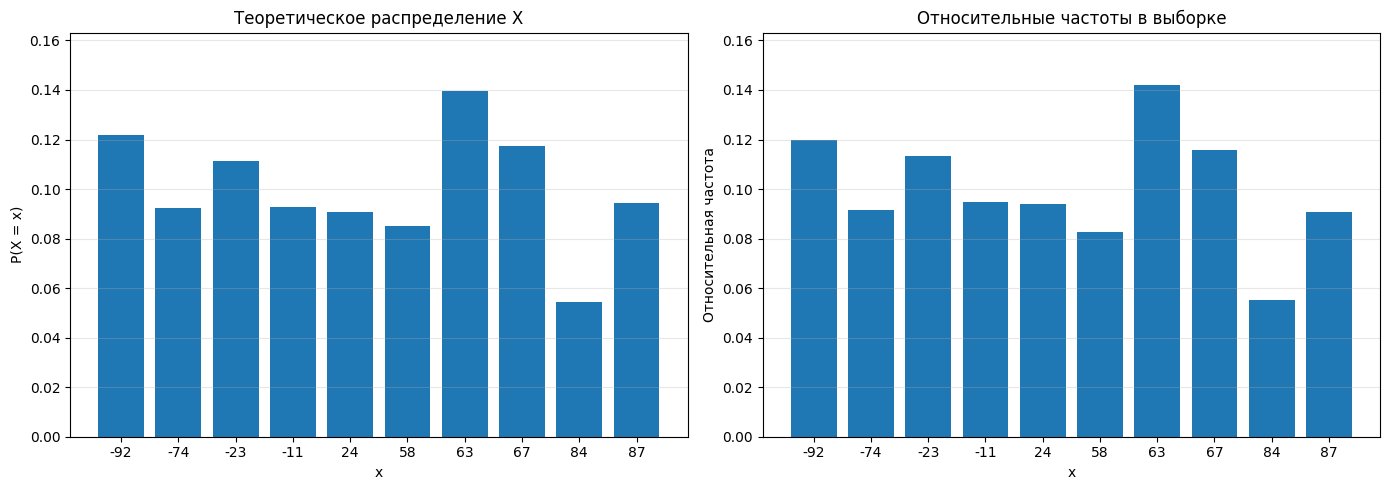

In [20]:
import matplotlib.pyplot as plt

relative_frequencies_x = (
    pd.Series(simulated_x)
    .value_counts(normalize=True)
    .reindex(marginal_x.index, fill_value=0)
)

frequency_table = pd.DataFrame({
    "x": marginal_x.index,
    "P(X = x)": marginal_x.values,
    "Относительная частота": relative_frequencies_x.values,
    "Разность": relative_frequencies_x.values - marginal_x.values,
})

display(
    frequency_table.style.hide(axis="index")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(marginal_x.index.astype(str), marginal_x.values)
axes[0].set_title("Теоретическое распределение X")
axes[0].set_xlabel("x")
axes[0].set_ylabel("P(X = x)")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(relative_frequencies_x.index.astype(str), relative_frequencies_x.values)
axes[1].set_title("Относительные частоты в выборке")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Относительная частота")
axes[1].grid(axis="y", alpha=0.3)

max_height = max(marginal_x.max(), relative_frequencies_x.max()) * 1.15
axes[0].set_ylim(0, max_height)
axes[1].set_ylim(0, max_height)

plt.tight_layout()
plt.show()

Гистограмма похожа на теоретическую, но не совпадает полностью, потому что значения были получены случайно.

По закону больших чисел, чем больше данных, тем ближе частоты к настоящим вероятностям. Так как было 10000 значений, результат получился достаточно близким.


3 Задание

Для наглядности сгенерируем 50000 значений из выбранного маргинального распределения X.

n_i,a_i,E(X),a_i - E(X)
10,11.300000,14.919900,-3.619900
20,6.700000,14.919900,-8.219900
50,5.640000,14.919900,-9.279900
100,9.170000,14.919900,-5.749900
200,15.145000,14.919900,0.225100
500,13.212000,14.919900,-1.707900
1000,15.555000,14.919900,0.635100
2000,15.831000,14.919900,0.911100
5000,14.604200,14.919900,-0.315700
10000,14.858400,14.919900,-0.061500


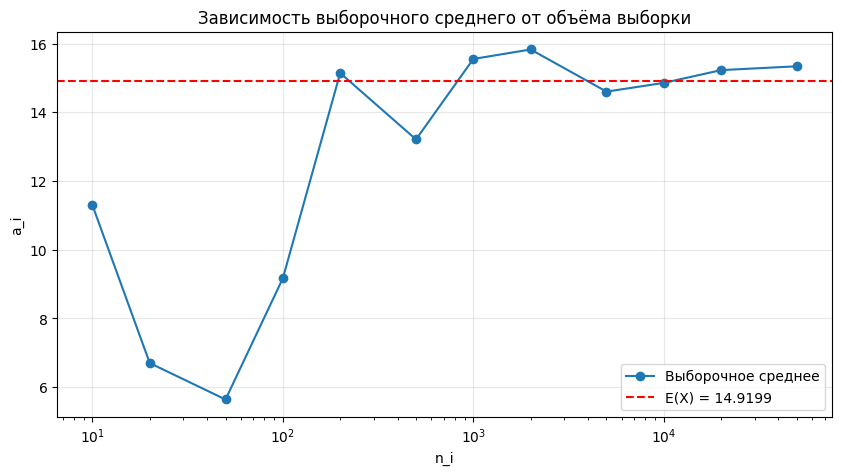

In [22]:
sample_sizes = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]
max_sample_size = max(sample_sizes)

simulated_x_large = [generate_x() for _ in range(max_sample_size)]

expected_x = (marginal_x.index.to_series() * marginal_x).sum()

sample_means = []

for n in sample_sizes:
    current_sum = 0

    for value in simulated_x_large[:n]:
        current_sum += value

    sample_means.append(current_sum / n)

means_table = pd.DataFrame({
    "n_i": sample_sizes,
    "a_i": sample_means,
    "E(X)": [expected_x] * len(sample_sizes),
    "a_i - E(X)": [mean - expected_x for mean in sample_means],
})

display(
    means_table.style.hide(axis="index")
)

plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, sample_means, marker="o", label="Выборочное среднее")
plt.axhline(expected_x, color="red", linestyle="--", label=f"E(X) = {expected_x:.4f}")
plt.xscale("log")
plt.title("Зависимость выборочного среднего от объёма выборки")
plt.xlabel("n_i")
plt.ylabel("a_i")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

На графике видно, что при маленьких $n_i$ среднее значение сильно меняется. Когда $n_i$ увеличивается, значения $a_i$ становятся ближе к теоретическому математическому ожиданию $E(X)$.

Это происходит из-за закона больших чисел: чем больше испытаний, тем ближе среднее значение к математическому ожиданию случайной величины.
